# Домашнее задание 4 - Непараметрические критерии


## Задача 1 (5 баллов)




1.   Сгенерить самостоятельно 2 распределения, нормальное с любыми параметрами и размером 1000 и биномиальное с параметрами 1, 0.5 и размером 100
2.   Для каждого распределения
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
    *   Проверить то что ваши распределения имееют общее распределение с помощью критерия однородности Смирнова
3.   Собрать новую выборку из ваших 2 сгенирированных распределений. Для этого взять случайных 900 элементов из нормального распределения и добавить к ним выборку с биномиальным распределением, чтобы снова получили выборки из 1000 элементов
4.   Для новой "собранной выборки"
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
5.  Из выборки с нормальным распределением получить новую выборку. Сделаем это с помощью "докидывания эффекта". Взять текущую выборку с нормальным распределением и рандомные 500 элементов увеличить на 5%, остальные оставим без изменений
6. Для новой выборки с "докинутым эффектом"
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
    *   Проверить то что ваши распределения(изначальное нормальное из п1 и полученное в п5) имееют общее распределение с помощью критерия однородности Смирнова





















In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [6]:
n_size, b_size = 1000, 100

loc, scale = 2, 10
n, p = 1, .5

normal_dist = stats.norm(loc=loc, scale=scale).rvs(n_size)
binom_dist = stats.binom(n=n, p=p).rvs(b_size)

In [49]:
from numpy.typing import NDArray

def task_1(dist: NDArray) -> None:
    plot = stats.probplot(dist, dist="norm", plot=plt)
    plt.show()

    print(stats.kstest(dist, "norm", args=(dist.mean(), dist.std(ddof=1))))

    print(stats.shapiro(dist))


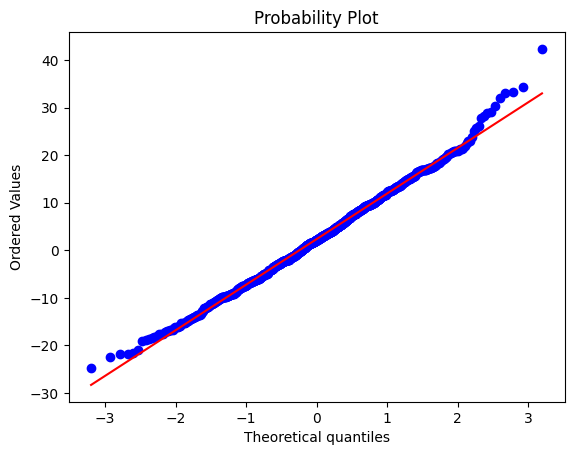

KstestResult(statistic=np.float64(0.020040123699125056), pvalue=np.float64(0.8089862060353455), statistic_location=np.float64(-1.9310484265268069), statistic_sign=np.int8(1))
ShapiroResult(statistic=np.float64(0.9961559735482498), pvalue=np.float64(0.014151399208668654))


In [50]:
task_1(normal_dist)

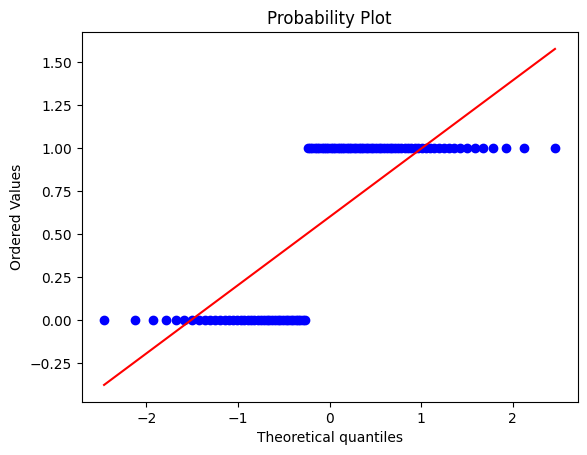

KstestResult(statistic=np.float64(0.39172002836160447), pvalue=np.float64(2.4573342504643608e-14), statistic_location=np.int64(1), statistic_sign=np.int8(-1))
ShapiroResult(statistic=np.float64(0.6216904904088889), pvalue=np.float64(1.1326188632189785e-14))


In [51]:
task_1(binom_dist)

In [52]:
stats.ks_2samp(normal_dist, binom_dist)

KstestResult(statistic=np.float64(0.555), pvalue=np.float64(1.2421683509618231e-26), statistic_location=np.float64(1.0), statistic_sign=np.int8(-1))

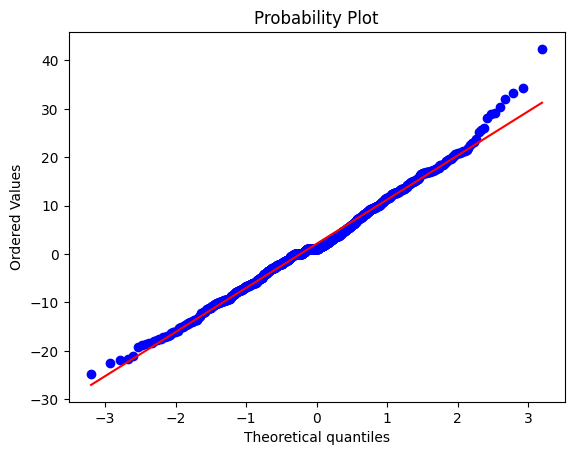

KstestResult(statistic=np.float64(0.05518258530855147), pvalue=np.float64(0.004353913459669854), statistic_location=np.float64(1.9107732819845498), statistic_sign=np.int8(1))
ShapiroResult(statistic=np.float64(0.992384239792445), pvalue=np.float64(5.091504203407623e-05))


In [53]:
assert len(normal_dist) > len(binom_dist)
almost_normal_dist = np.concatenate((normal_dist[len(binom_dist):], binom_dist))

task_1(almost_normal_dist)

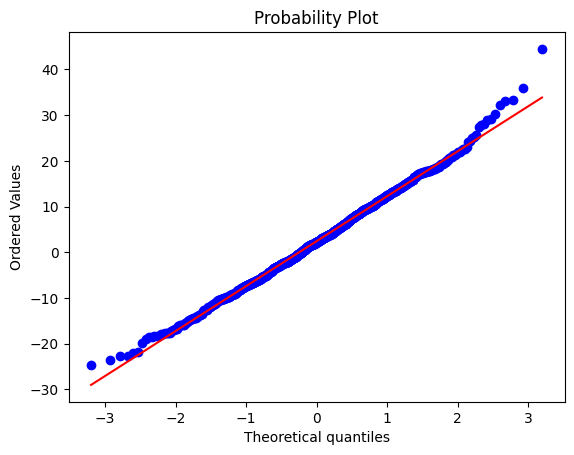

KstestResult(statistic=np.float64(0.021509145910469485), pvalue=np.float64(0.7354432418807954), statistic_location=np.float64(4.1756480451268185), statistic_sign=np.int8(1))
ShapiroResult(statistic=np.float64(0.9963691594827465), pvalue=np.float64(0.02009608020512623))


In [54]:
multiplier = 1.05
n_multiply = 500
idx = np.random.choice(n_size, n_multiply, replace=False)

dist = normal_dist.copy()

dist[idx] *= multiplier

task_1(dist)

In [56]:
stats.ks_2samp(normal_dist, dist)

KstestResult(statistic=np.float64(0.017), pvalue=np.float64(0.9987234512860412), statistic_location=np.float64(17.06827045912172), statistic_sign=np.int8(1))

## Задача 2 (4 балла)

Для данных из файла employees.xls постройте гистограмму для переменной SALARY. Проверьте нормальность этих данных с помощью:
  * Q-Q plot
  * Критерия Колмогорова
  * Критерия Шапиро-Уилка


In [19]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/employees.xls >> employees.xls

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 26624  100 26624    0     0  71381      0 --:--:-- --:--:-- --:--:-- 71569


In [22]:
import pandas as pd

df = pd.read_excel('employees.xls')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  100 non-null    object
 1   GENDER      100 non-null    object
 2   DEPART      100 non-null    object
 3   EDUC        100 non-null    object
 4   AGE         100 non-null    int64 
 5   HEIGHT      100 non-null    int64 
 6   SENIOR      100 non-null    int64 
 7   SALARY      100 non-null    int64 
 8   INI_PROF    100 non-null    int64 
 9   CUR_PROF    100 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 7.9+ KB


In [23]:
df.head()

,Unnamed: 0,GENDER,DEPART,EDUC,AGE,HEIGHT,SENIOR,SALARY,INI_PROF,CUR_PROF
0,Alexander,Female,Ship,College,22,63,4,23400,82,90
1,Arcones,Male,Package,College,49,65,17,40400,89,123
2,Barber,Male,Bake,College,36,67,8,29400,77,93
3,Barrera,Male,Package,HS,37,67,3,24800,102,108
4,Bester,Male,Ship,Grad,43,66,11,31200,82,104


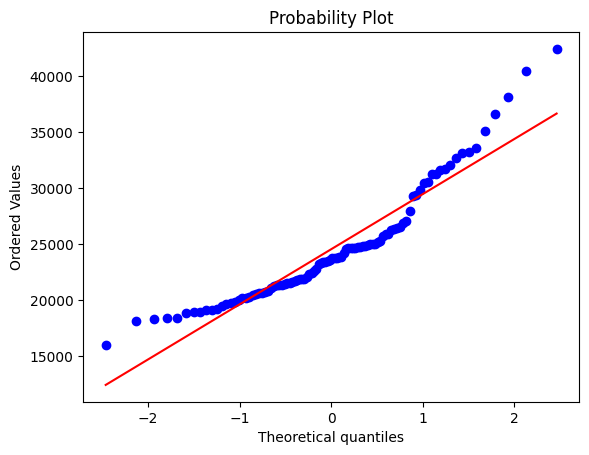

KstestResult(statistic=np.float64(0.152518581459004), pvalue=np.float64(0.016985059239319866), statistic_location=np.int64(25000), statistic_sign=np.int8(1))
ShapiroResult(statistic=np.float64(0.9015022004875934), pvalue=np.float64(1.664645028598051e-06))


In [24]:
salary = df['SALARY'].to_numpy()

task_1(salary)

## Задача 3 (3 балла)

Для данных из файла employees.xls проверить с помощью критерия знаков и рангового критерия гипотезу что медианная зарплата равна 25000

In [31]:
from statsmodels.stats.descriptivestats import sign_test
expected_salary = 25000

_, p_value = sign_test(salary, mu0=expected_salary)

print(f"p-value: {p_value:.6f}")

p-value: 0.000490


In [32]:
print(stats.wilcoxon(salary - expected_salary))

WilcoxonResult(statistic=np.float64(1809.5), pvalue=np.float64(0.04131952571720401))


## Задача 4 (3 балла)

В файле anorexia.txt записан вес пациентов до и после начала терапии от анорексии. С помощью критерия знаков и рангового критерия проверить, была ли эффективна данная терапия

In [33]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/anorexia.txt >> anorexia.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   355  100   355    0     0   1006      0 --:--:-- --:--:-- --:--:--  1008


In [34]:
df = pd.read_csv('anorexia.txt', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Before  29 non-null     float64
 1   After   29 non-null     float64
dtypes: float64(2)
memory usage: 592.0 bytes


In [35]:
df.head()

,Before,After
0,80.5,82.2
1,84.9,85.6
2,81.5,81.4
3,82.6,81.9
4,79.9,76.4


In [36]:
diff = (df['After'] - df['Before']).to_numpy()
sign_test(diff)


(np.float64(3.5), np.float64(0.26493089646101))

In [37]:
stats.wilcoxon(df["After"], df["Before"])

WilcoxonResult(statistic=np.float64(131.5), pvalue=np.float64(0.06551516801118851))

## Задача 5 (3 балла)

В файле seattle.txt записаны цены на объекты недвижимости в одном районе из районов Сиетла в 2001 и 2002 году (объекты выбирались случайно). Изменились ли средние цены в этом районе за год? Проверить это с помощью критерия знаков и рангового критерия

In [38]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/seattle.txt >> seattle.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   996  100   996    0     0   2658      0 --:--:-- --:--:-- --:--:--  2663


In [39]:
df = pd.read_csv('seattle.txt', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   100 non-null    float64
 1   Year    100 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [40]:
df.head()

,Price,Year
0,142.0,2002
1,232.0,2002
2,132.5,2002
3,200.0,2002
4,362.0,2002


In [44]:
prices_01 = df[df['Year'] == 2001]['Price'].to_numpy()
prices_02 = df[df['Year'] == 2002]['Price'].to_numpy()

stats.mannwhitneyu(prices_02, prices_01, alternative="greater")

MannwhitneyuResult(statistic=np.float64(1204.5), pvalue=np.float64(0.6244246260134891))

## Задача 6 (3 балла)

В рамках исследования эффективности лекарства
пациенты с синдромом дефицита внимания и гиперактивностью в течение недели принимали либо лекарство, либо плацебо. В конце недели каждый пациент проходил тест на способность к подавлению импульсивных поведенческих реакций. Был ли эффект от применения лекарства? Данные находятся в файле methylphenidate.txt.

In [45]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/methylphenidate.txt >> methylphenidate.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   168  100   168    0     0    441      0 --:--:-- --:--:-- --:--:--   442


In [46]:
df = pd.read_csv('methylphenidate.txt', sep=' ')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Placebo          24 non-null     int64
 1   Methylphenidate  24 non-null     int64
dtypes: int64(2)
memory usage: 512.0 bytes


In [47]:
df.head()

,Placebo,Methylphenidate
0,57,62
1,27,49
2,32,30
3,31,34
4,34,38


In [48]:
stats.mannwhitneyu(
    df["Methylphenidate"], df["Placebo"], alternative="greater"
)

MannwhitneyuResult(statistic=np.float64(370.0), pvalue=np.float64(0.04609734480136834))

## Задача 7 (2 балла)


1.   Сгенерировать выборки с нормальным распределением без выбросов, докинуть эффект на одну из них равномерно и с помощью распределения
2.   То же, что и в п1, но выборки с выбросами сделать
3.   Для случаев из п1 и п2 бутстрэпом оценить: среднее, медиану, 25% перцентиль, построить доверительные интервалы для статистик (речь о разницах средних/медиан/перцентилей для групп)
4.   Для случаев из п1 и п2 оценить среднее т-тестом и Манном-Уитни. Сравнить с результатами бутстрэпа. Сделать выводы. Сравниваем точечные оценки (на бутстрэпе их тоже считаем)

Примечание:
- Бутстреп считать минимум на 1000 итераций
- Для докидывания эффекта с помощью распределения возьмите распределение из stats, параметры задаются исходя из параметров изначального вектора и желаемого эффекта


In [83]:
loc, scale = 2, 10
size = 1000

multiplier = 1.1
effect_loc, effect_scale = 0.5, 0.1
# 1
dist_1 = stats.norm(loc=loc, scale=scale).rvs(size)
dist_2 = stats.norm(loc=loc, scale=scale).rvs(size)


dist_2_uniform = dist_2*multiplier
dist_2_dist = dist_2.copy() + stats.norm(loc=effect_loc, scale=effect_scale).rvs(size)

In [84]:
# 2
outlier_loc, outlier_scale, outlier_size = 10, 20, 100

dist_2_uniform_outlier = np.concatenate((dist_2_uniform.copy(), stats.norm(loc=outlier_loc, scale=outlier_scale).rvs(outlier_size)))
dist_2_dist_outlier = np.concatenate((dist_2_dist.copy(), stats.norm(loc=outlier_loc, scale=outlier_scale).rvs(outlier_size)))

In [85]:
from typing import Callable, Iterable, Tuple

Statistic = Callable[[NDArray], np.float64]

def get_bootstrap_array(arr: NDArray) -> NDArray:
    return np.random.choice(arr, replace=True, size=len(arr))

def calc_bootstrap_statistic(arr: NDArray, stat: Statistic, size: int = 1000):
    result = np.empty(size)
    for i in range(size):
        result[i] = stat(get_bootstrap_array(arr))
    return result


def test_with_bootstrap(
        dists: Tuple[NDArray, NDArray],
        stat: Statistic,
        n_boot: int,
        alpha: float = .05
) -> None:
    assert len(dists) == 2
    left, right = calc_bootstrap_statistic(dists[0], stat, n_boot), calc_bootstrap_statistic(dists[1], stat, n_boot)
    diff = right - left
    left_ci, right_ci = np.percentile(diff, [100 * (1 - alpha), 100 * alpha])
    print(f"Statistic: {stat.__name__}, CI({alpha*100}%): ({left_ci:.2f}, {right_ci:.2f})")
    plt.hist(diff, bins=int(np.sqrt(n_boot)), color='blue', label='difference')
    plt.axvline(left_ci, color='red', linestyle='--', label='left CI')
    plt.axvline(right_ci, color='red', linestyle='--', label='right CI')
    plt.legend()
    plt.title(f'Bootstrap CI for {stat.__name__}')
    plt.show()
    
    


----------------------------------------------------------------------------------------------------
Distributions: norm, norm+uniform
Statistic: mean, CI(5.0%): (0.59, -0.86)


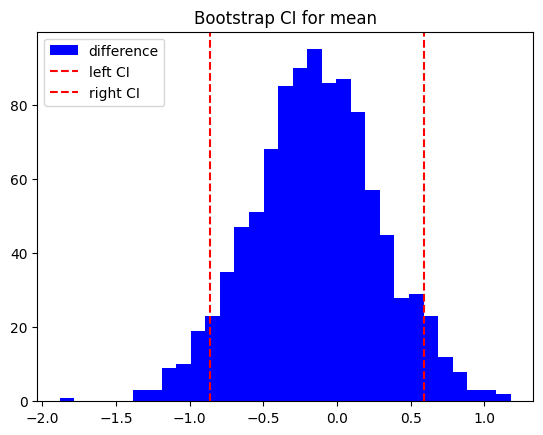

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+uniform
Statistic: median, CI(5.0%): (0.48, -1.58)


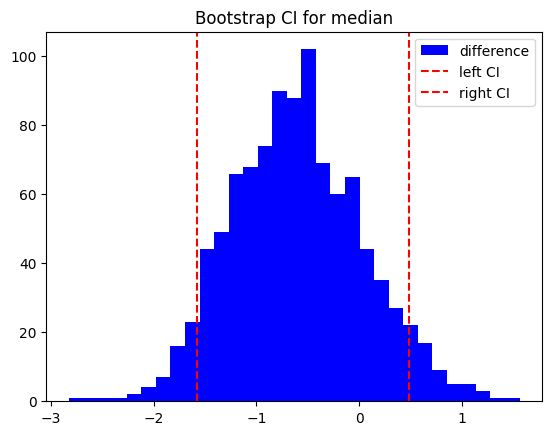

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+uniform
Statistic: q1, CI(5.0%): (0.64, -1.15)


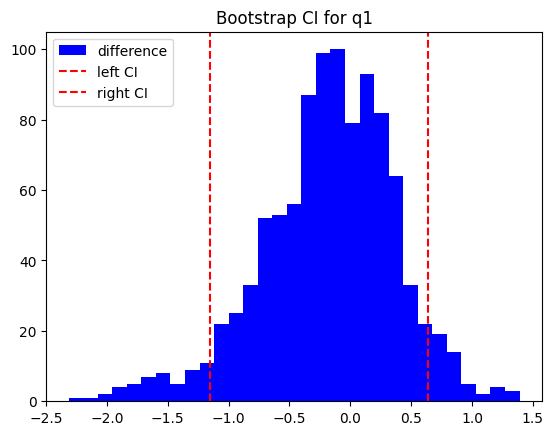

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+norm
Statistic: mean, CI(5.0%): (0.91, -0.48)


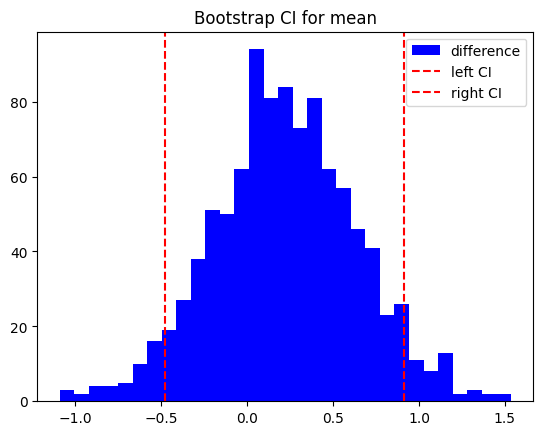

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+norm
Statistic: median, CI(5.0%): (0.78, -1.19)


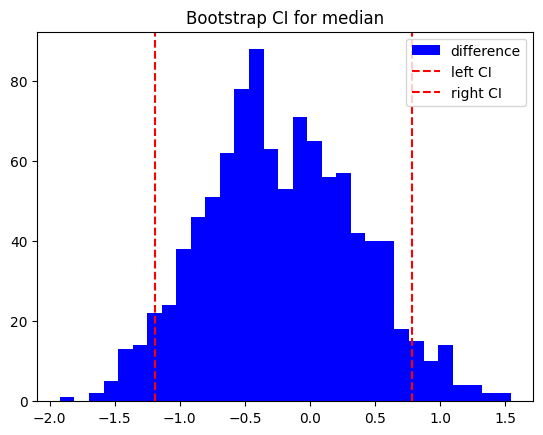

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+norm
Statistic: q1, CI(5.0%): (1.63, -0.11)


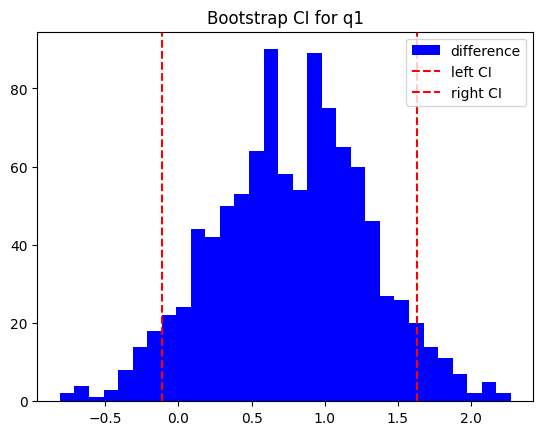

----------------------------------------------------------------------------------------------------
Distributions: norm+uniform, norm+norm
Statistic: mean, CI(5.0%): (1.07, -0.40)


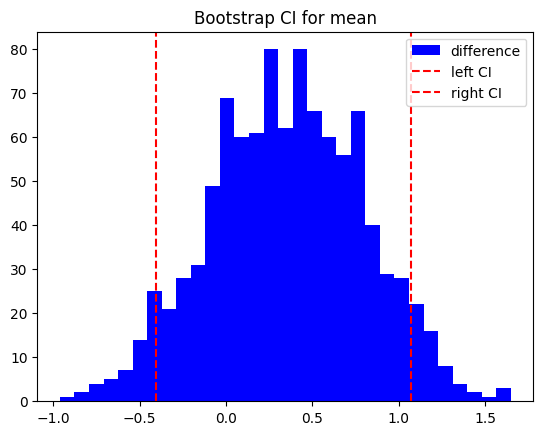

----------------------------------------------------------------------------------------------------
Distributions: norm+uniform, norm+norm
Statistic: median, CI(5.0%): (1.30, -0.53)


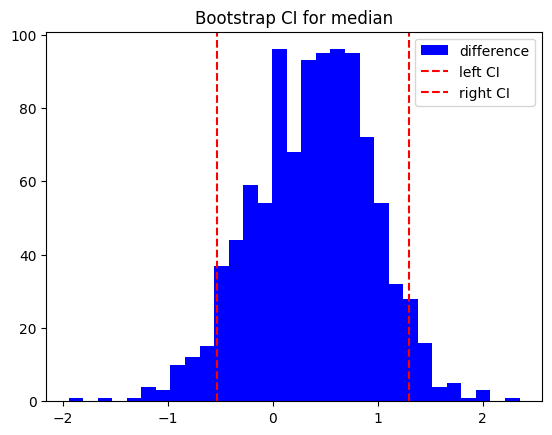

----------------------------------------------------------------------------------------------------
Distributions: norm+uniform, norm+norm
Statistic: q1, CI(5.0%): (1.92, 0.06)


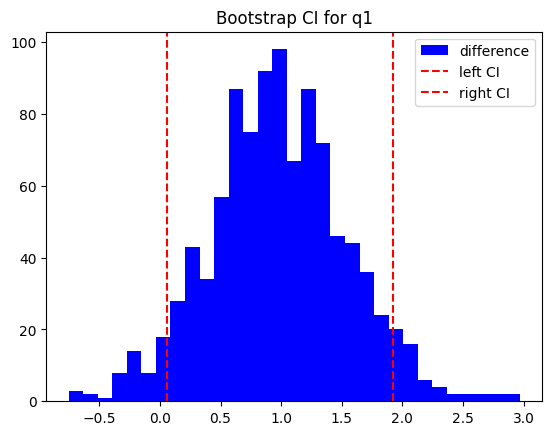

In [87]:
def q1(data: NDArray) -> np.float64:
    return np.percentile(data, 25)

statistics = (
    np.mean,
    np.median,
    q1
)

n_boot = 1000
alpha = .05
# task_1 
dists = (dist_1, dist_2_uniform, dist_2_dist)
names = ('norm', 'norm+uniform', 'norm+norm')
for i in range(len(dists)):
    for j in range(i+1, len(dists)):
        for stat in statistics:
            print('-'*100)
            print(f"Distributions: {names[i]}, {names[j]}")
            test_with_bootstrap((dists[i], dists[j]), stat, n_boot, alpha)

## Задача 8 (2 балла)

Сгенерировать 2 выборки из нормального распределения с 1000 элементов каждая.
- Оцените на этих данных мощность и корректность t-test и Манна-Уитни
- Докиньте выбросы в обе группы и проверьте как изменится мощность и корректность

Для оценки использовать минимум 1000 итераций